# **Import libraries**

In [ ]:
import os
import category_encoders
import yaml
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
from ydata_profiling import ProfileReport

warnings.filterwarnings('ignore')

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import catboost as cb

c:\Users\DELL\cvd_5\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
fram = pd.read_csv('framingham.csv')

uci = pd.read_csv('cleveland.csv')

# **Try `ydata_profiling`**

In [ ]:
profile = ProfileReport(fram, title="Framingham Data Profiling Report")
profile.to_file("framingham_data_profile.html")

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 66.84it/s]


In [ ]:
profile2 = ProfileReport(uci, title="UCI Data Profiling Report")
profile2.to_file("uci_data_profile.html")

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 62.67it/s]


In [ ]:
fram.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [ ]:
fram.isnull().sum()

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

> `glucose, education, BPMeds, totChol, cigsPerDay, BMI`

In [ ]:
uci.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
dtype: int64

> `ca, thal`

# **EDA**

In [ ]:
with open('config/fram.yaml', 'r') as file:
    config_fram = yaml.safe_load(file)

with open('config/uci.yaml', 'r') as file:
    config_uci = yaml.safe_load(file)

In [ ]:
num_data_fram = fram[config_fram['numerical']]
num_data_fram.describe().T

,count,mean,std,min,25%,50%,75%,max
age,4240.0,49.580189,8.572942,32.00,42.00,49.0,56.00,70.0
cigsPerDay,4211.0,9.005937,11.922462,0.00,0.00,0.0,20.00,70.0
totChol,4190.0,236.699523,44.591284,107.00,206.00,234.0,263.00,696.0
sysBP,4240.0,132.354599,22.033300,83.50,117.00,128.0,144.00,295.0
diaBP,4240.0,82.897759,11.910394,48.00,75.00,82.0,90.00,142.5
BMI,4221.0,25.800801,4.079840,15.54,23.07,25.4,28.04,56.8
heartRate,4239.0,75.878981,12.025348,44.00,68.00,75.0,83.00,143.0
glucose,3852.0,81.963655,23.954335,40.00,71.00,78.0,87.00,394.0


In [ ]:
num_data_uci = uci[config_uci['numerical']]
num_data_uci.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2
ca,299.0,0.672241,0.937438,0.0,0.0,0.0,1.0,3.0


In [ ]:
target_freq = fram[config_fram['target']].mean() * 100
target_freq

np.float64(15.188679245283017)

In [ ]:
# Change all other values that are higher than 1 to 1
uci['num'] = uci['num'].apply(lambda x: 1 if x > 0 else 0)
target_freq_uci = uci['num'].mean() * 100
target_freq_uci

np.float64(45.87458745874587)

In [ ]:
uci.to_csv('./data/uci.csv', index=False)

In [ ]:
fram.isnull().sum()

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

## **Numerical features**

### **Histograms & Boxplots for numerical features**

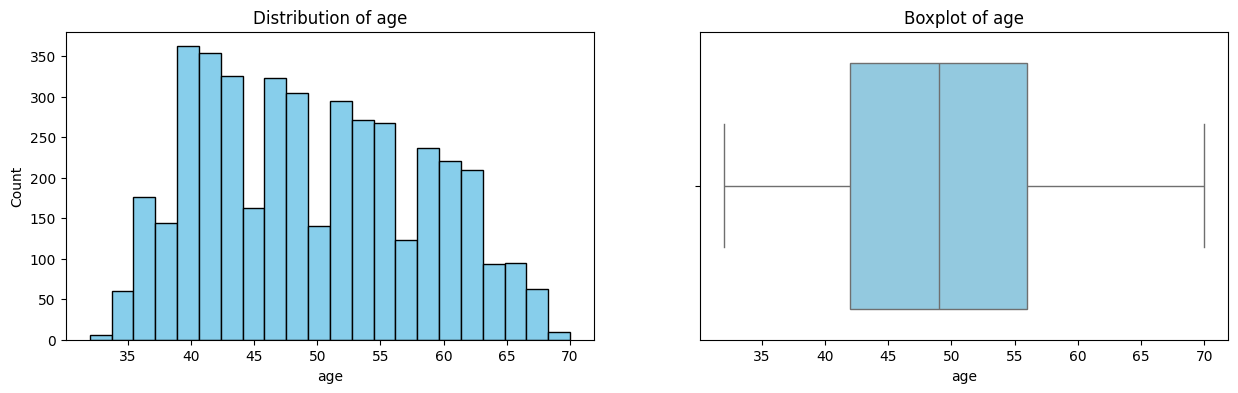

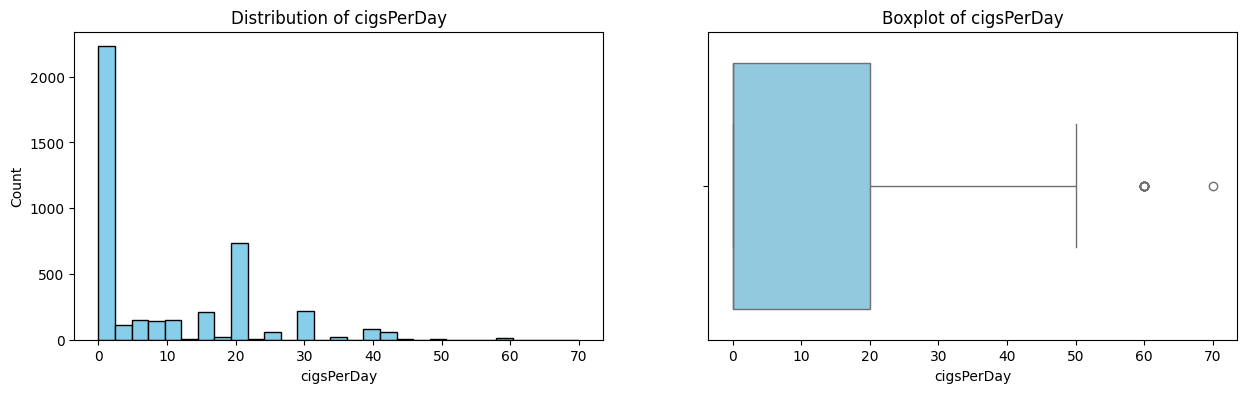

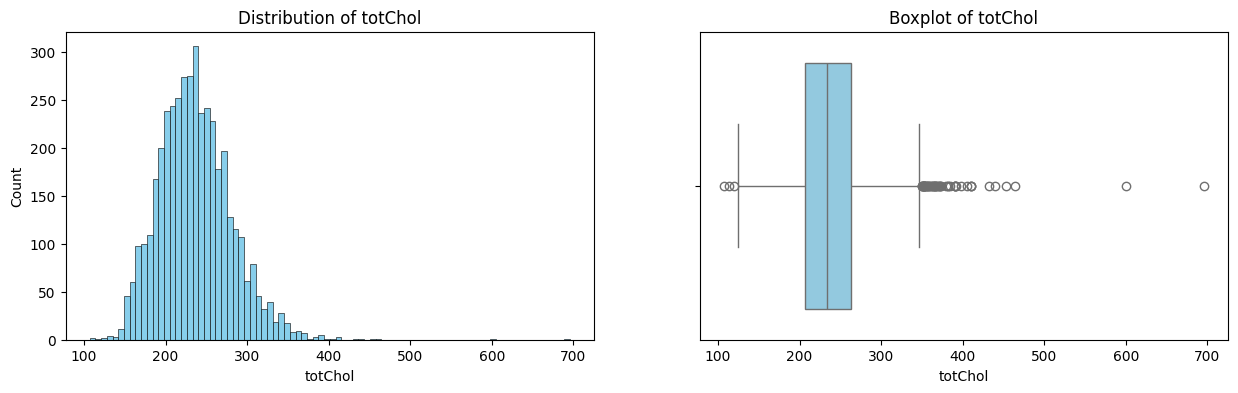

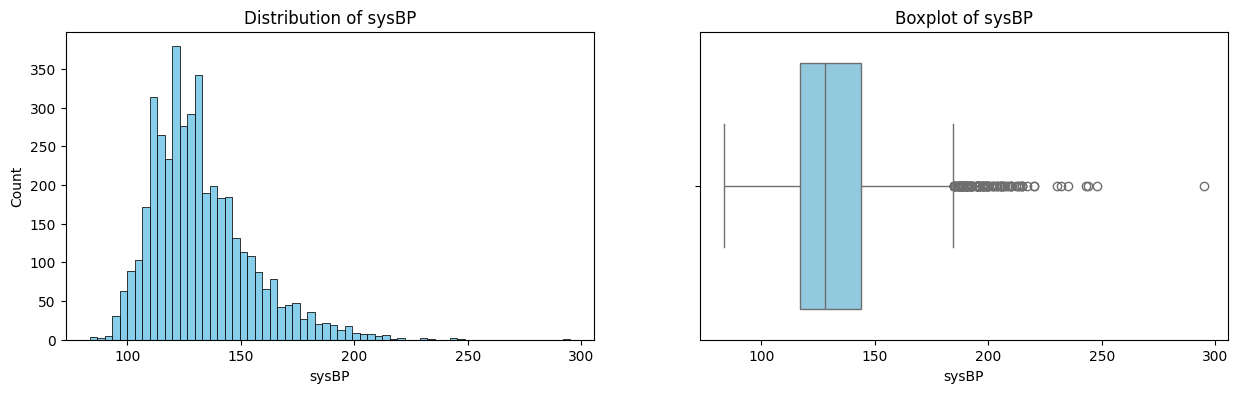

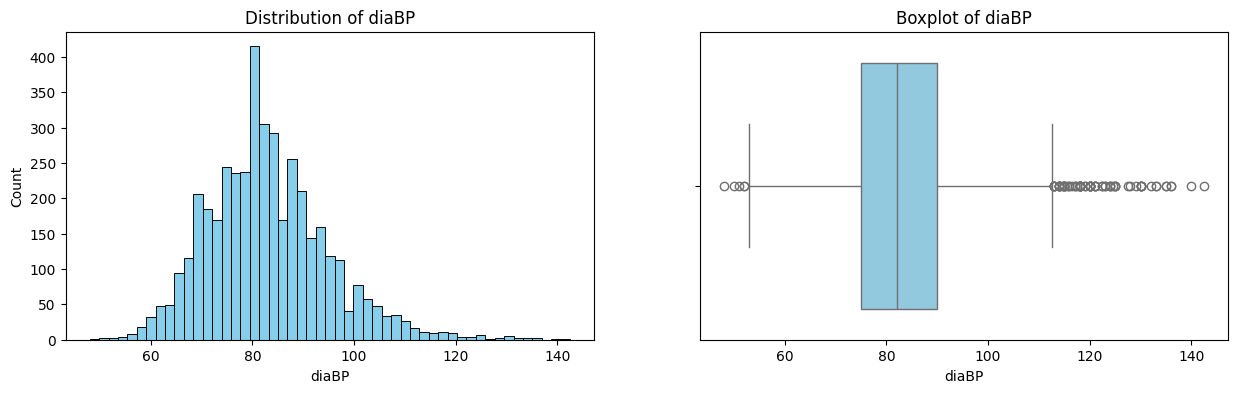

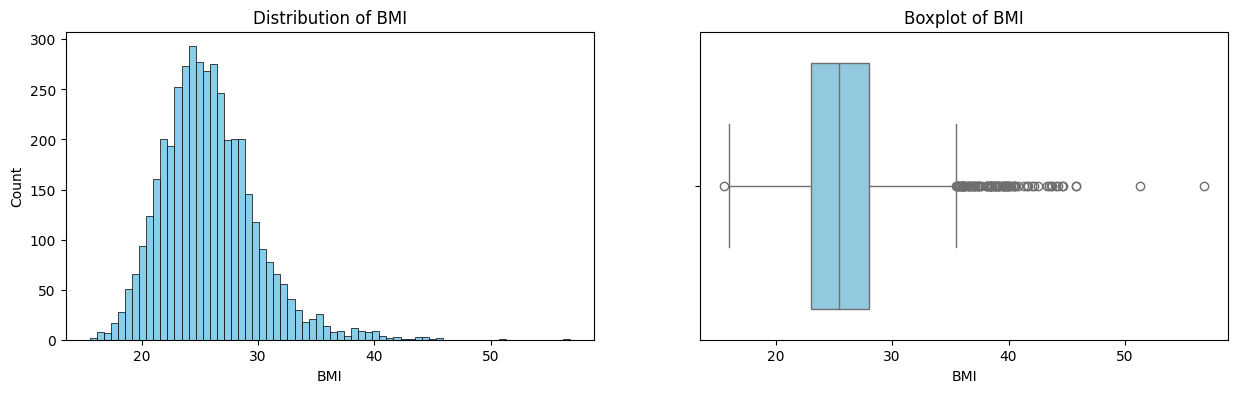

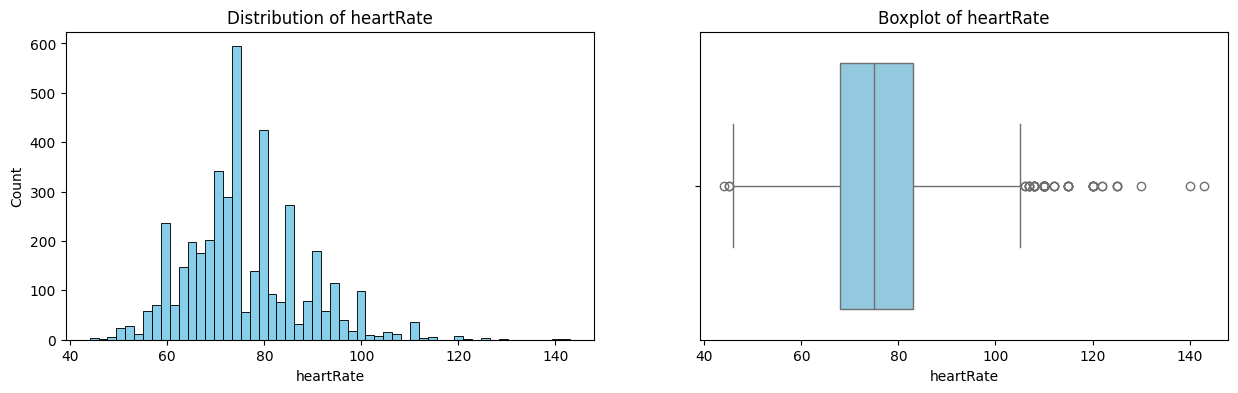

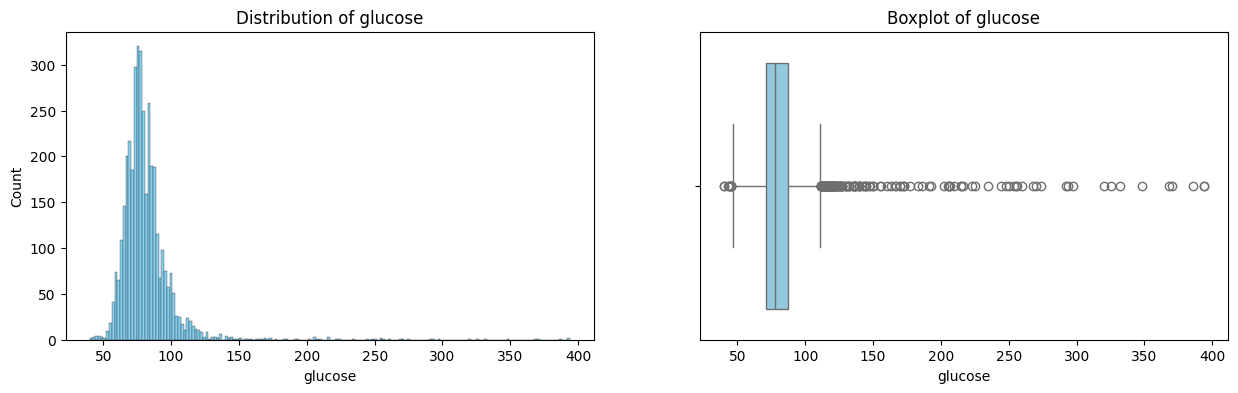

In [ ]:
for col in num_data_fram.columns:
    fig, ax = plt.subplots(1, 2, figsize=(15, 4))

    # Histogram: distribution of the feature
    sns.histplot(num_data_fram[col], ax=ax[0], color='skyblue', edgecolor='black', alpha=1)
    ax[0].set_title(f'Distribution of {col}')
    ax[0].set_xlabel(col)
    ax[0].set_ylabel('Count')

    # Boxplot: spread of feature, identify outliers
    sns.boxplot(x=num_data_fram[col], ax=ax[1], color='skyblue')
    ax[1].set_title(f'Boxplot of {col}')
    ax[1].set_xlabel(col)

    plt.show()

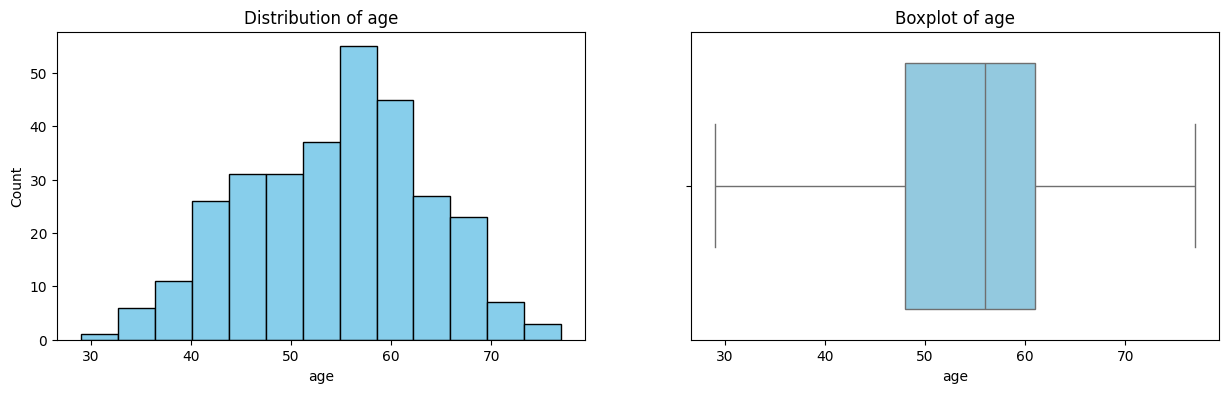

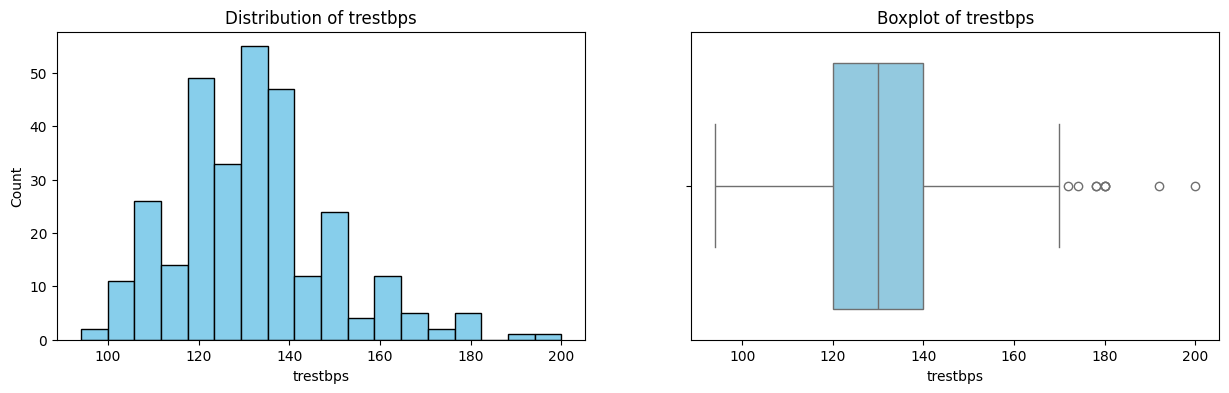

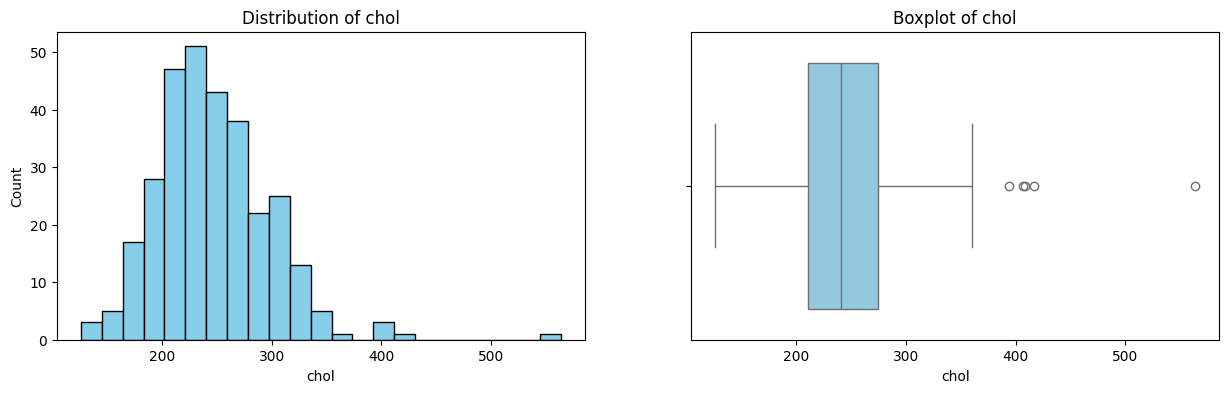

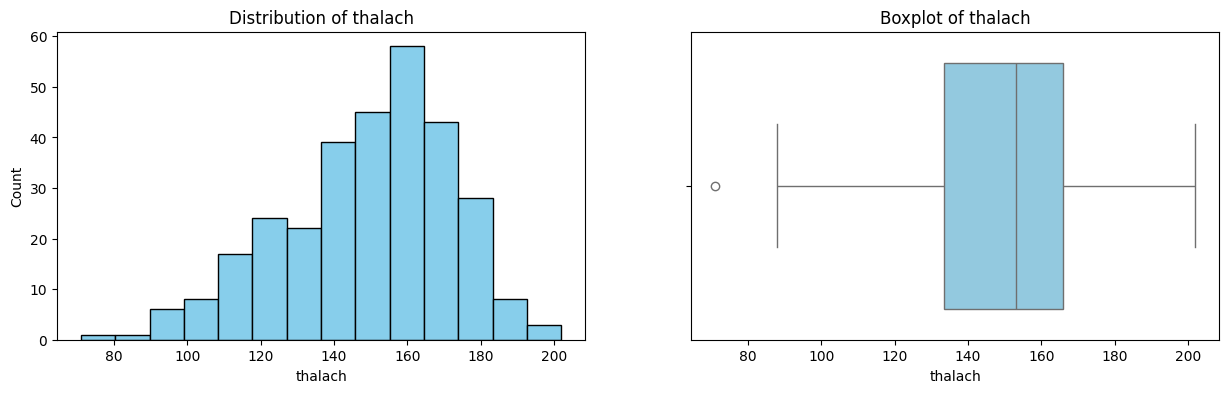

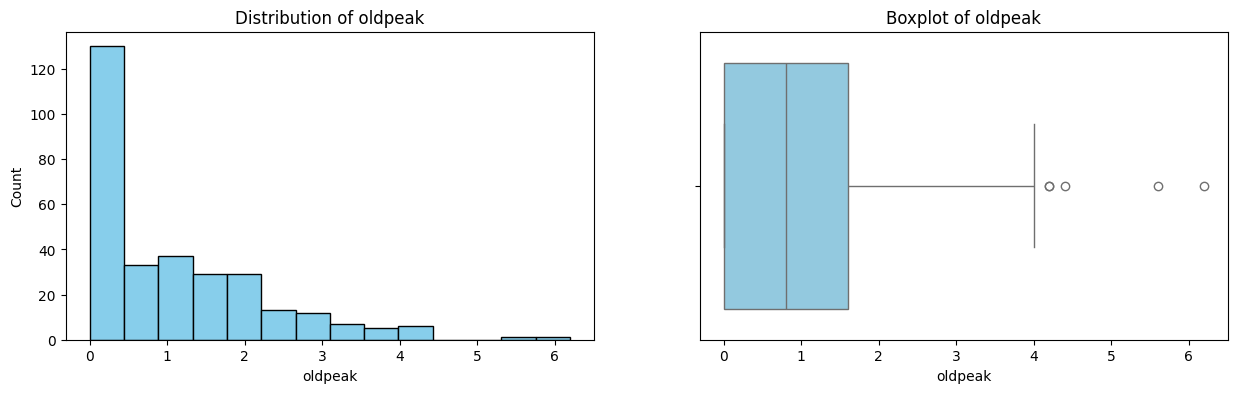

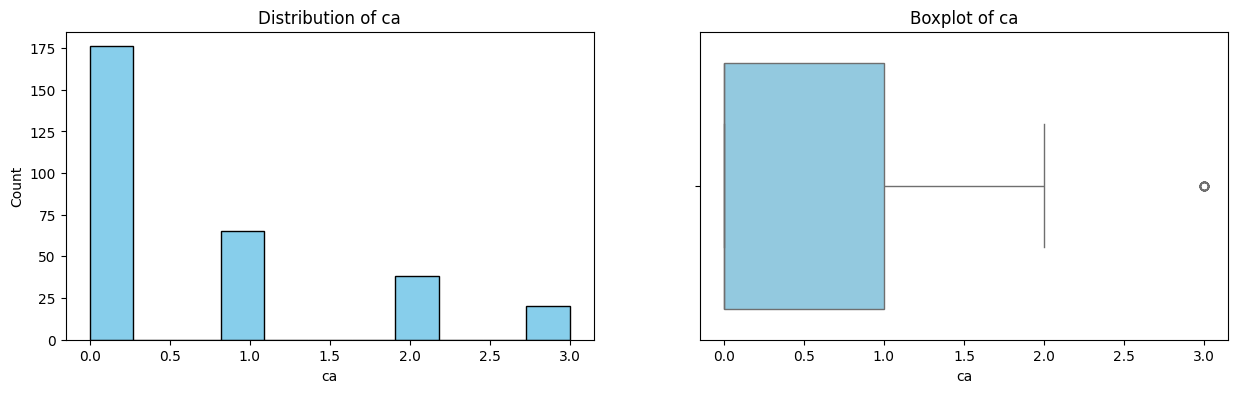

In [ ]:
for col in num_data_uci.columns:
    fig, ax = plt.subplots(1, 2, figsize=(15, 4))

    # Histogram: distribution of the feature
    sns.histplot(num_data_uci[col], ax=ax[0], color='skyblue', edgecolor='black', alpha=1)
    ax[0].set_title(f'Distribution of {col}')
    ax[0].set_xlabel(col)
    ax[0].set_ylabel('Count')

    # Boxplot: spread of feature, identify outliers
    sns.boxplot(x=num_data_uci[col], ax=ax[1], color='skyblue')
    ax[1].set_title(f'Boxplot of {col}')
    ax[1].set_xlabel(col)

    plt.show()

### **KDE plots**

>  To compare distributions for numerical features for different values of `target`

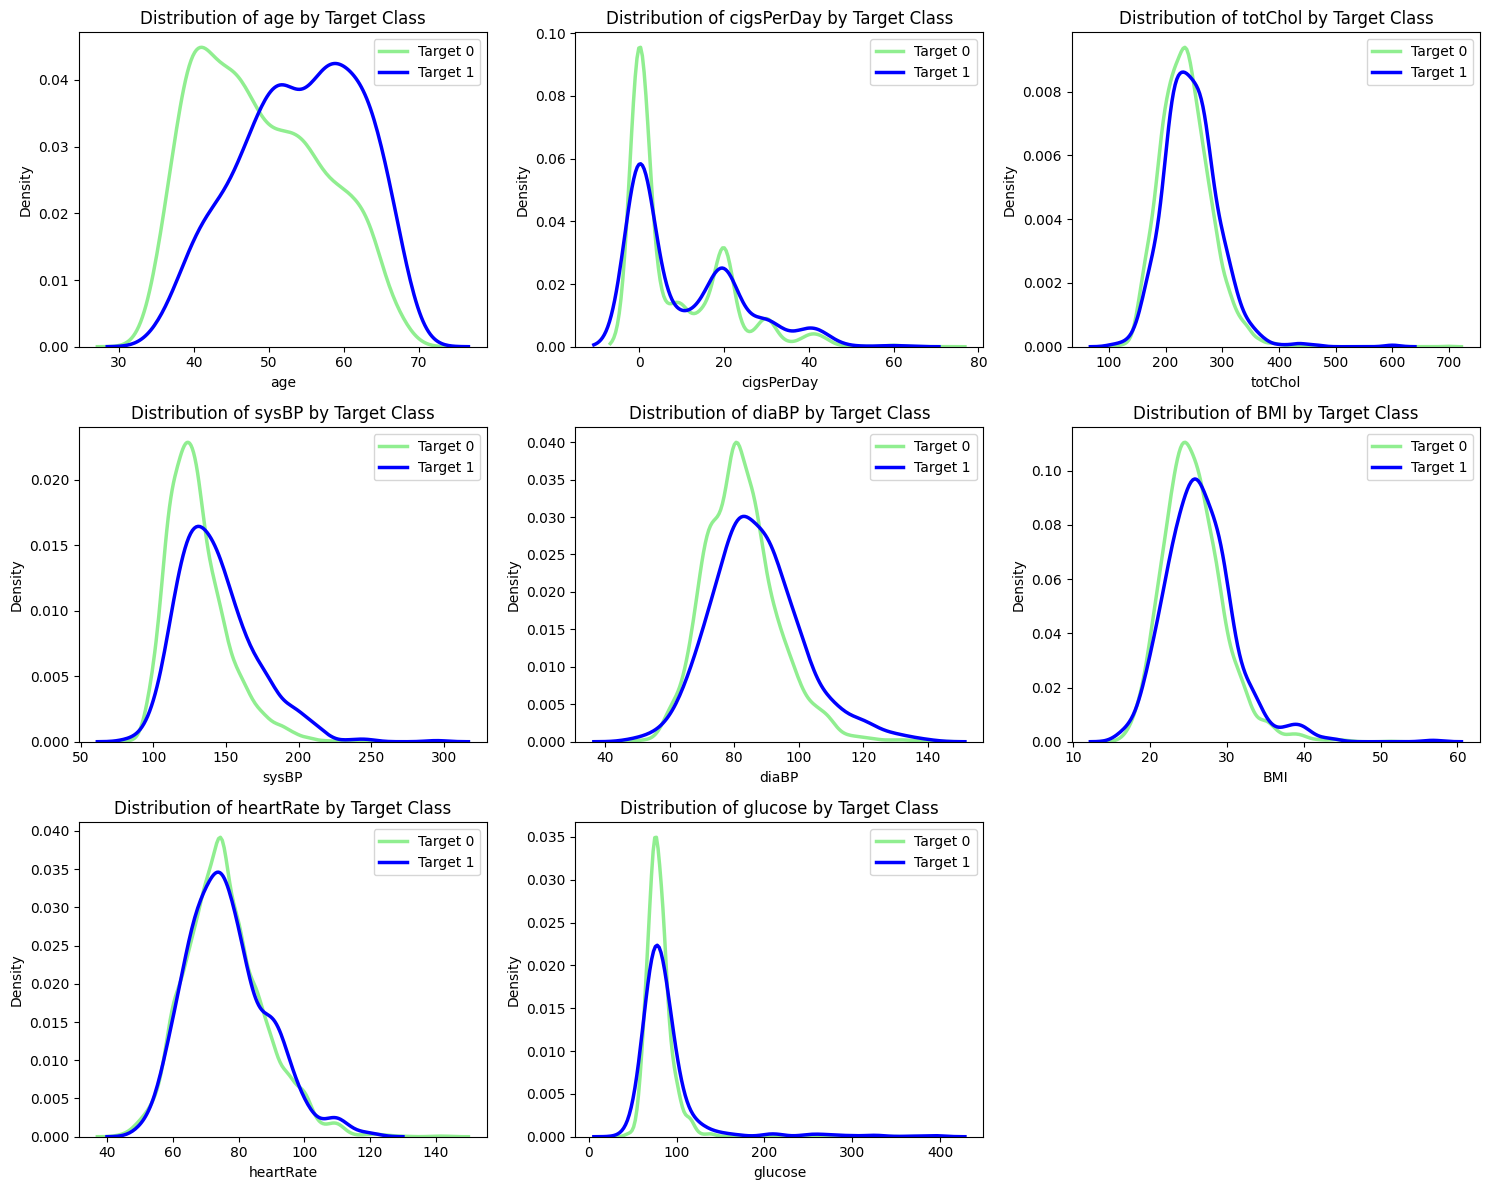

In [ ]:
n_plots = len(num_data_fram.columns)
n_cols = 3
n_rows = (n_plots + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 5, n_rows * 4))
for i, col in enumerate(num_data_fram.columns):
    ax = plt.subplot(n_rows, n_cols, i + 1)

    color_mapping = {0: 'lightgreen',
                     1: 'blue'}
    class_vals = fram['TenYearCHD'].unique()
    for class_val in class_vals:
        subset = num_data_fram[fram['TenYearCHD'] == class_val]
        sns.kdeplot(subset[col], ax=ax, label=f'Target {class_val}', color=color_mapping[class_val], linewidth=2.5)

    ax.set_title(f'Distribution of {col} by Target Class')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend()

plt.tight_layout()
plt.show()

> The KDE plots indicate that `age` has remarkably distinct distributions when comparing patients who may have disease in 10 years versus those who may not have.

--> `age` may be `significant factor` for the model.

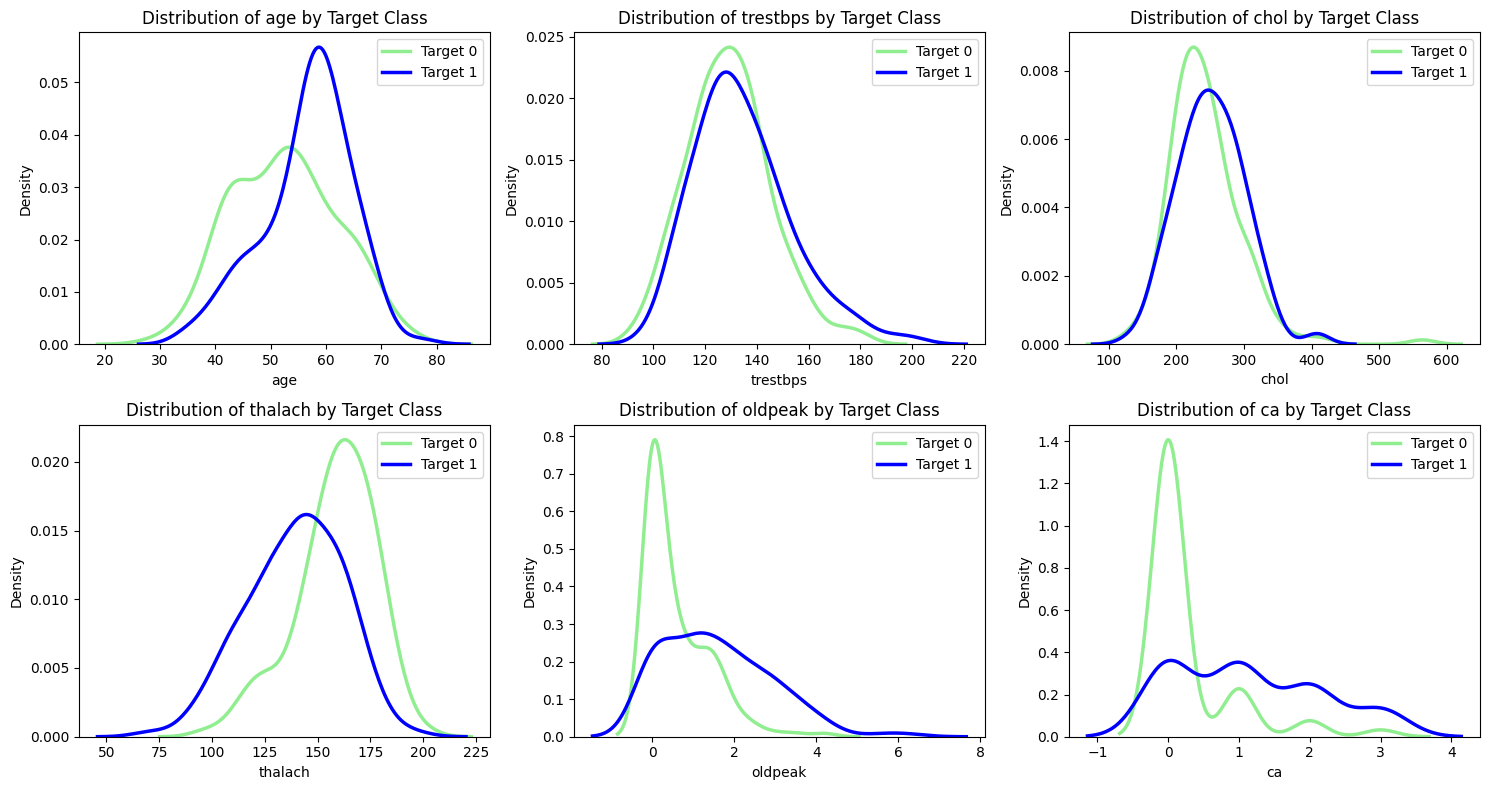

In [ ]:
n_plots = len(num_data_uci.columns)
n_cols = 3
n_rows = (n_plots + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 5, n_rows * 4))
for i, col in enumerate(num_data_uci.columns):
    ax = plt.subplot(n_rows, n_cols, i + 1)

    color_mapping = {0: 'lightgreen',
                     1: 'blue'}
    class_vals = uci['num'].unique()
    for class_val in class_vals:
        subset = num_data_uci[uci['num'] == class_val]
        sns.kdeplot(subset[col], ax=ax, label=f'Target {class_val}', color=color_mapping[class_val], linewidth=2.5)

    ax.set_title(f'Distribution of {col} by Target Class')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend()

plt.tight_layout()
plt.show()

> `age, thalach, oldpeak, ca`

### **Correlation Matrix**

> Linear relationship between features

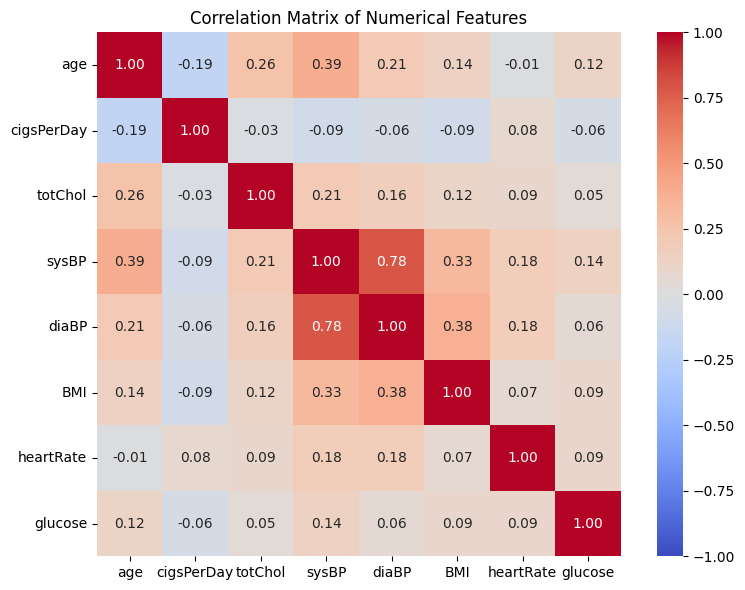

In [ ]:
corr_matrix = num_data_fram.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, square=True, fmt='.2f', vmin=-1, vmax=1, center=0, cmap='coolwarm')

plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.title('Correlation Matrix of Numerical Features')

plt.tight_layout()
plt.show()

> Positive strong correlation between `sysBP` and `diaBP`, positive medium correlation between `age` + `sysBP`; `diaBP` + `BMI` and `sysBP` + `BMI`.

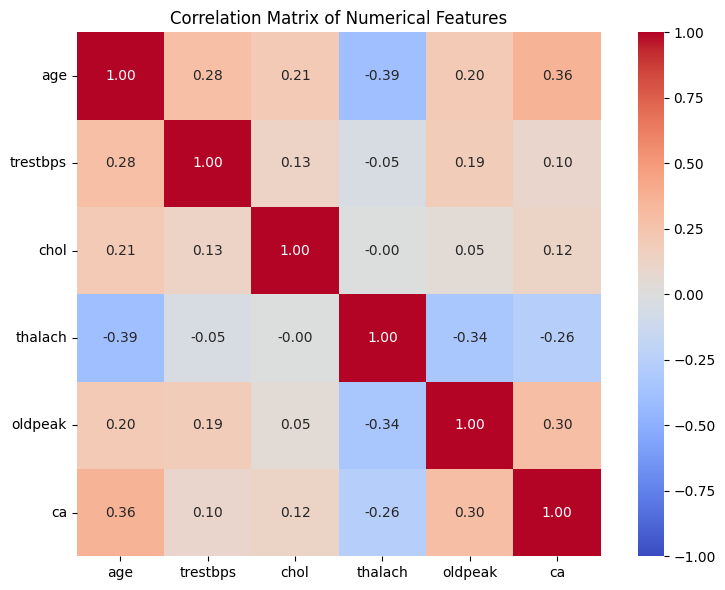

In [ ]:
corr_matrix = num_data_uci.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, square=True, fmt='.2f', vmin=-1, vmax=1, center=0, cmap='coolwarm')

plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.title('Correlation Matrix of Numerical Features')

plt.tight_layout()
plt.show()

## **Categorical Features**

### **Bar Chart**

In [ ]:
cat_data_fram = fram[config_fram['ordinal'] + config_fram['binary']]
cat_data_uci = uci[config_uci['ordinal'] + config_uci['binary'] + config_uci['nominal']]

#### **Separately**

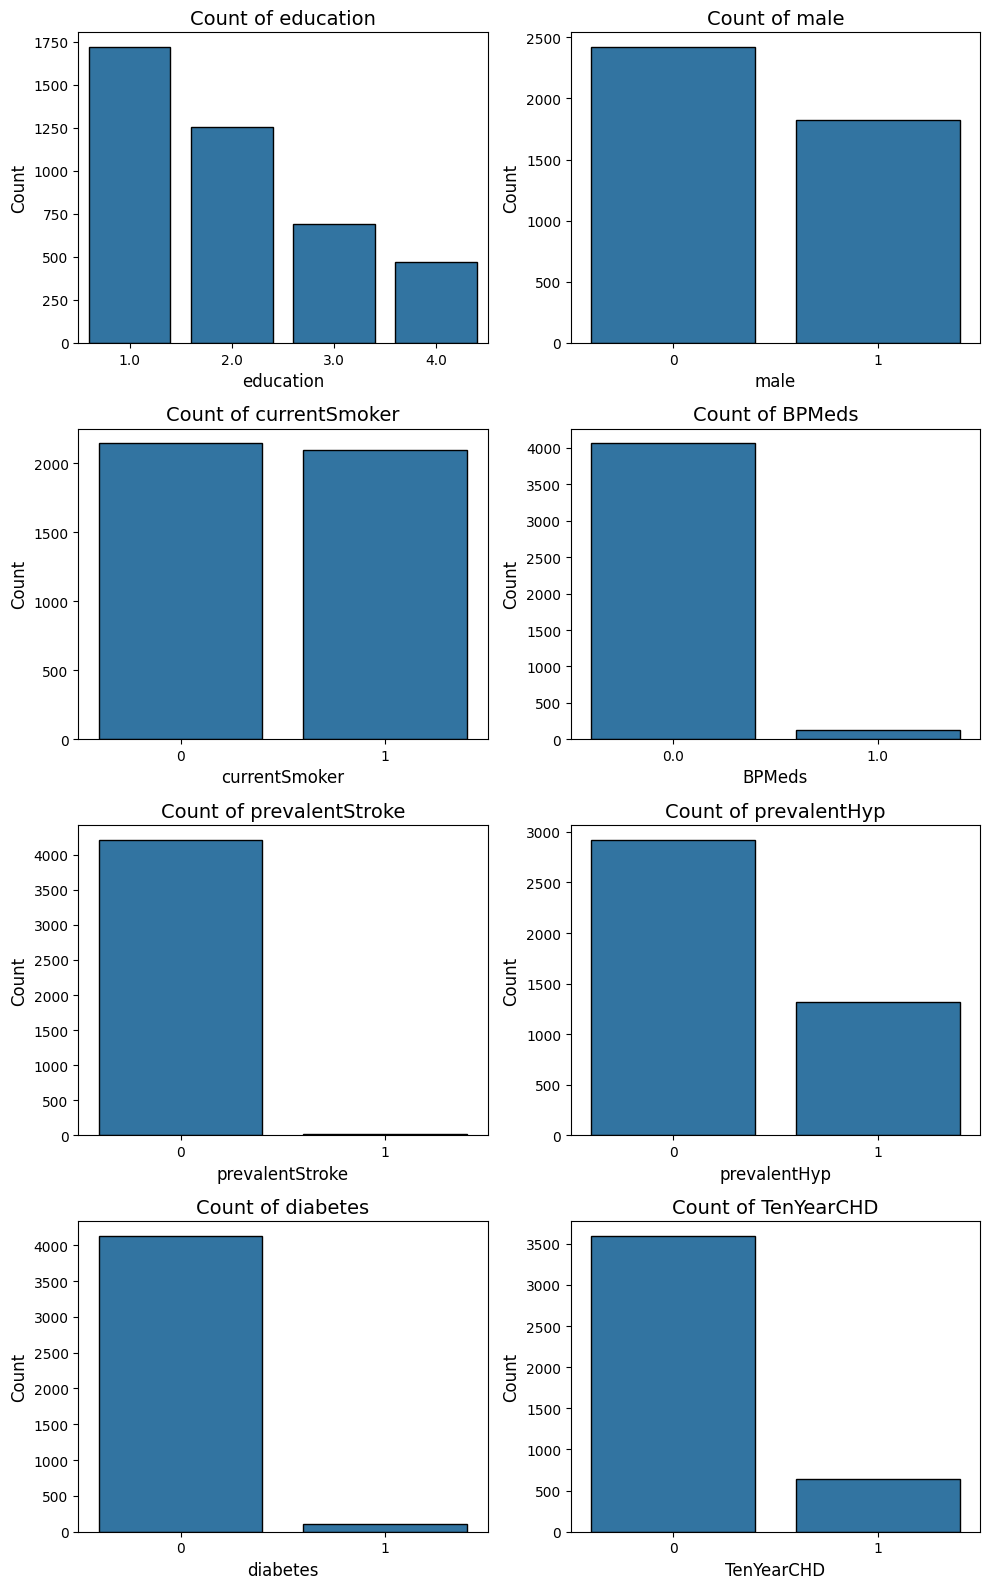

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(10, 16))
axes = axes.flatten()
for i, col in enumerate(cat_data_fram.columns.tolist() + ['TenYearCHD']):
    ax = axes[i]
    sns.countplot(x=fram[col], ax=ax, edgecolor='black')
    ax.set_title(f'Count of {col}', fontsize=14)
    ax.set_xlabel(col, fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
plt.tight_layout()
plt.show()

> Low cardinality, but high scarcity

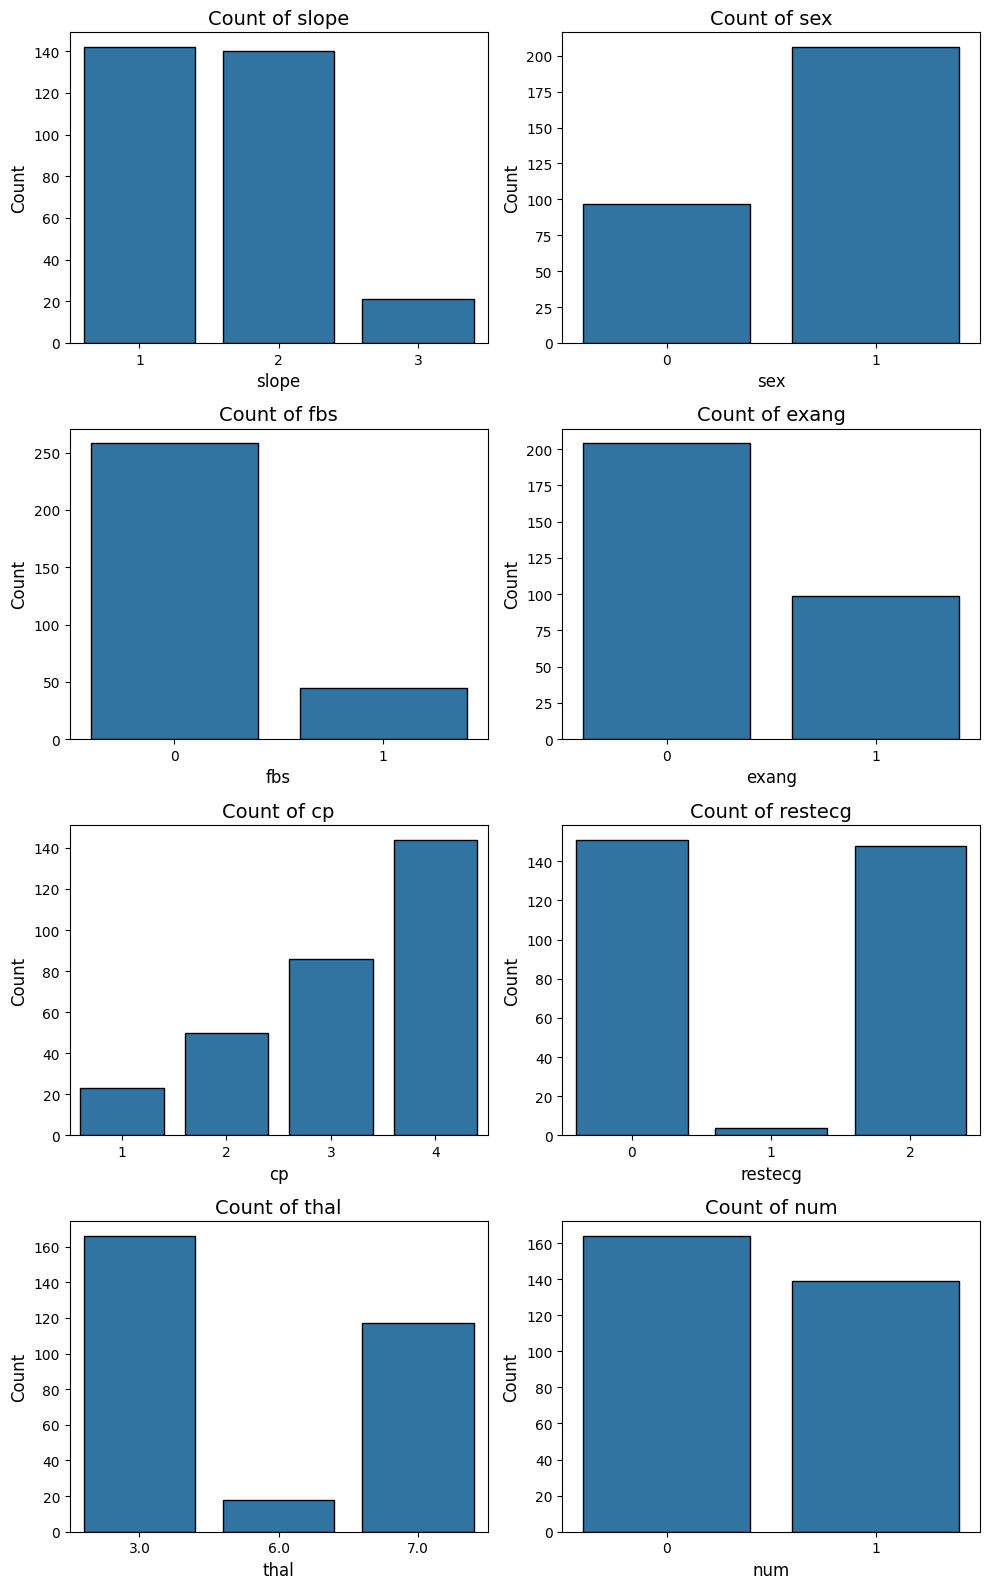

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(10, 16))
axes = axes.flatten()
for i, col in enumerate(cat_data_uci.columns.tolist() + ['num']):
    ax = axes[i]
    sns.countplot(x=uci[col], ax=ax, edgecolor='black')
    ax.set_title(f'Count of {col}', fontsize=14)
    ax.set_xlabel(col, fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
plt.tight_layout()
plt.show()

> Almost all categorical columns are imbalanced, however, the target variable `num` is quite balance.

#### **By `target` class**

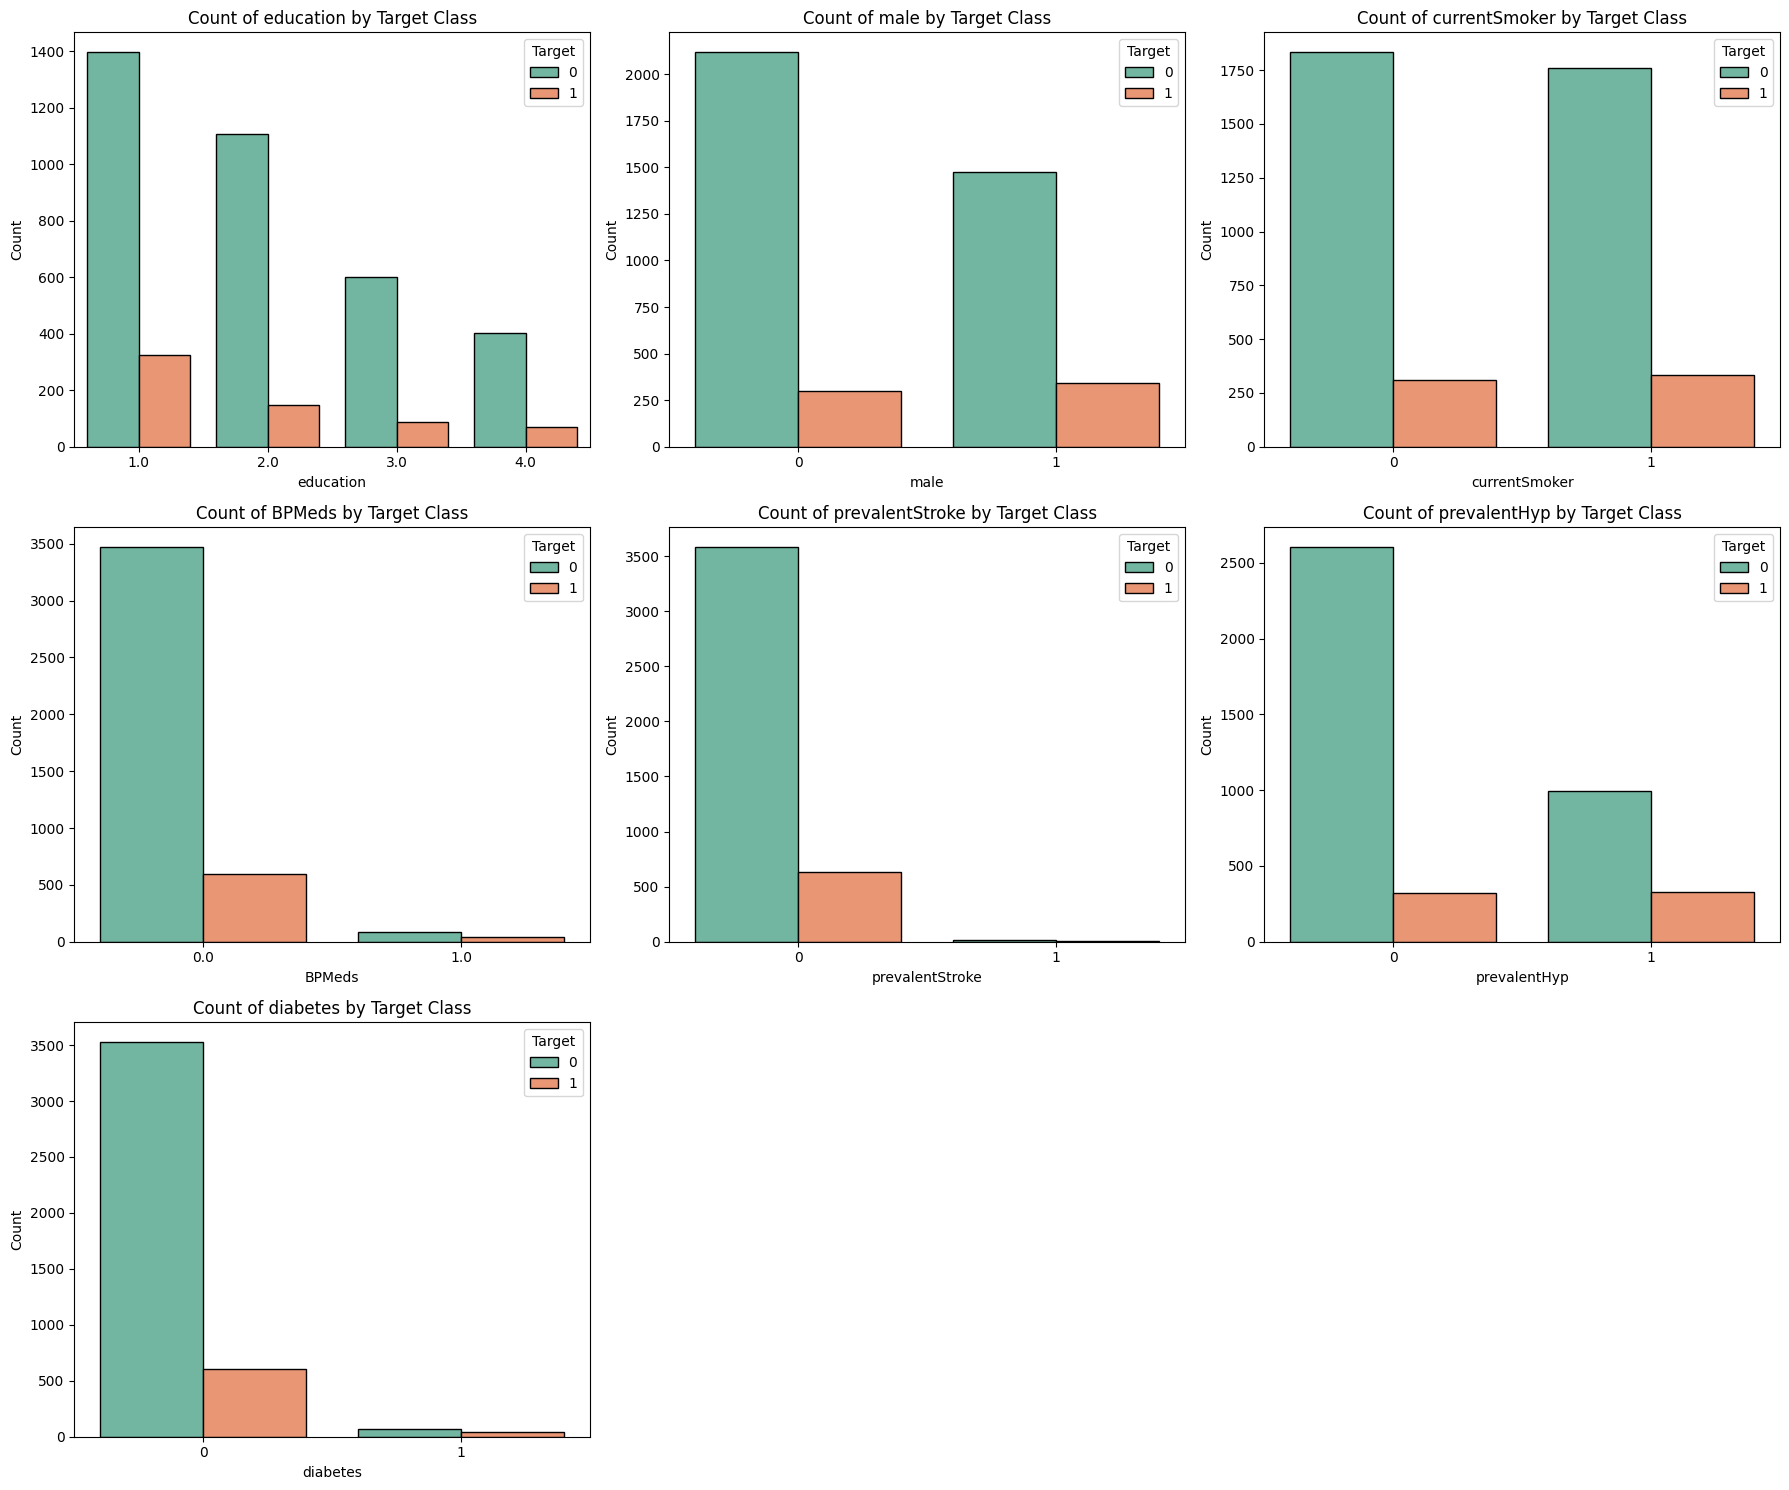

In [ ]:
n_cols = 3
n_rows = (len(cat_data_fram.columns) + n_cols - 1) // n_cols  # enough rows for all columns

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(n_cols * 6, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(cat_data_fram.columns):
    ax = axes[i]
    sns.countplot(x=cat_data_fram[col], hue=fram['TenYearCHD'], ax=ax, palette='Set2', edgecolor='black')
    ax.set_title(f'Count of {col} by Target Class')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.legend(title='Target', labels=['0', '1'])

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


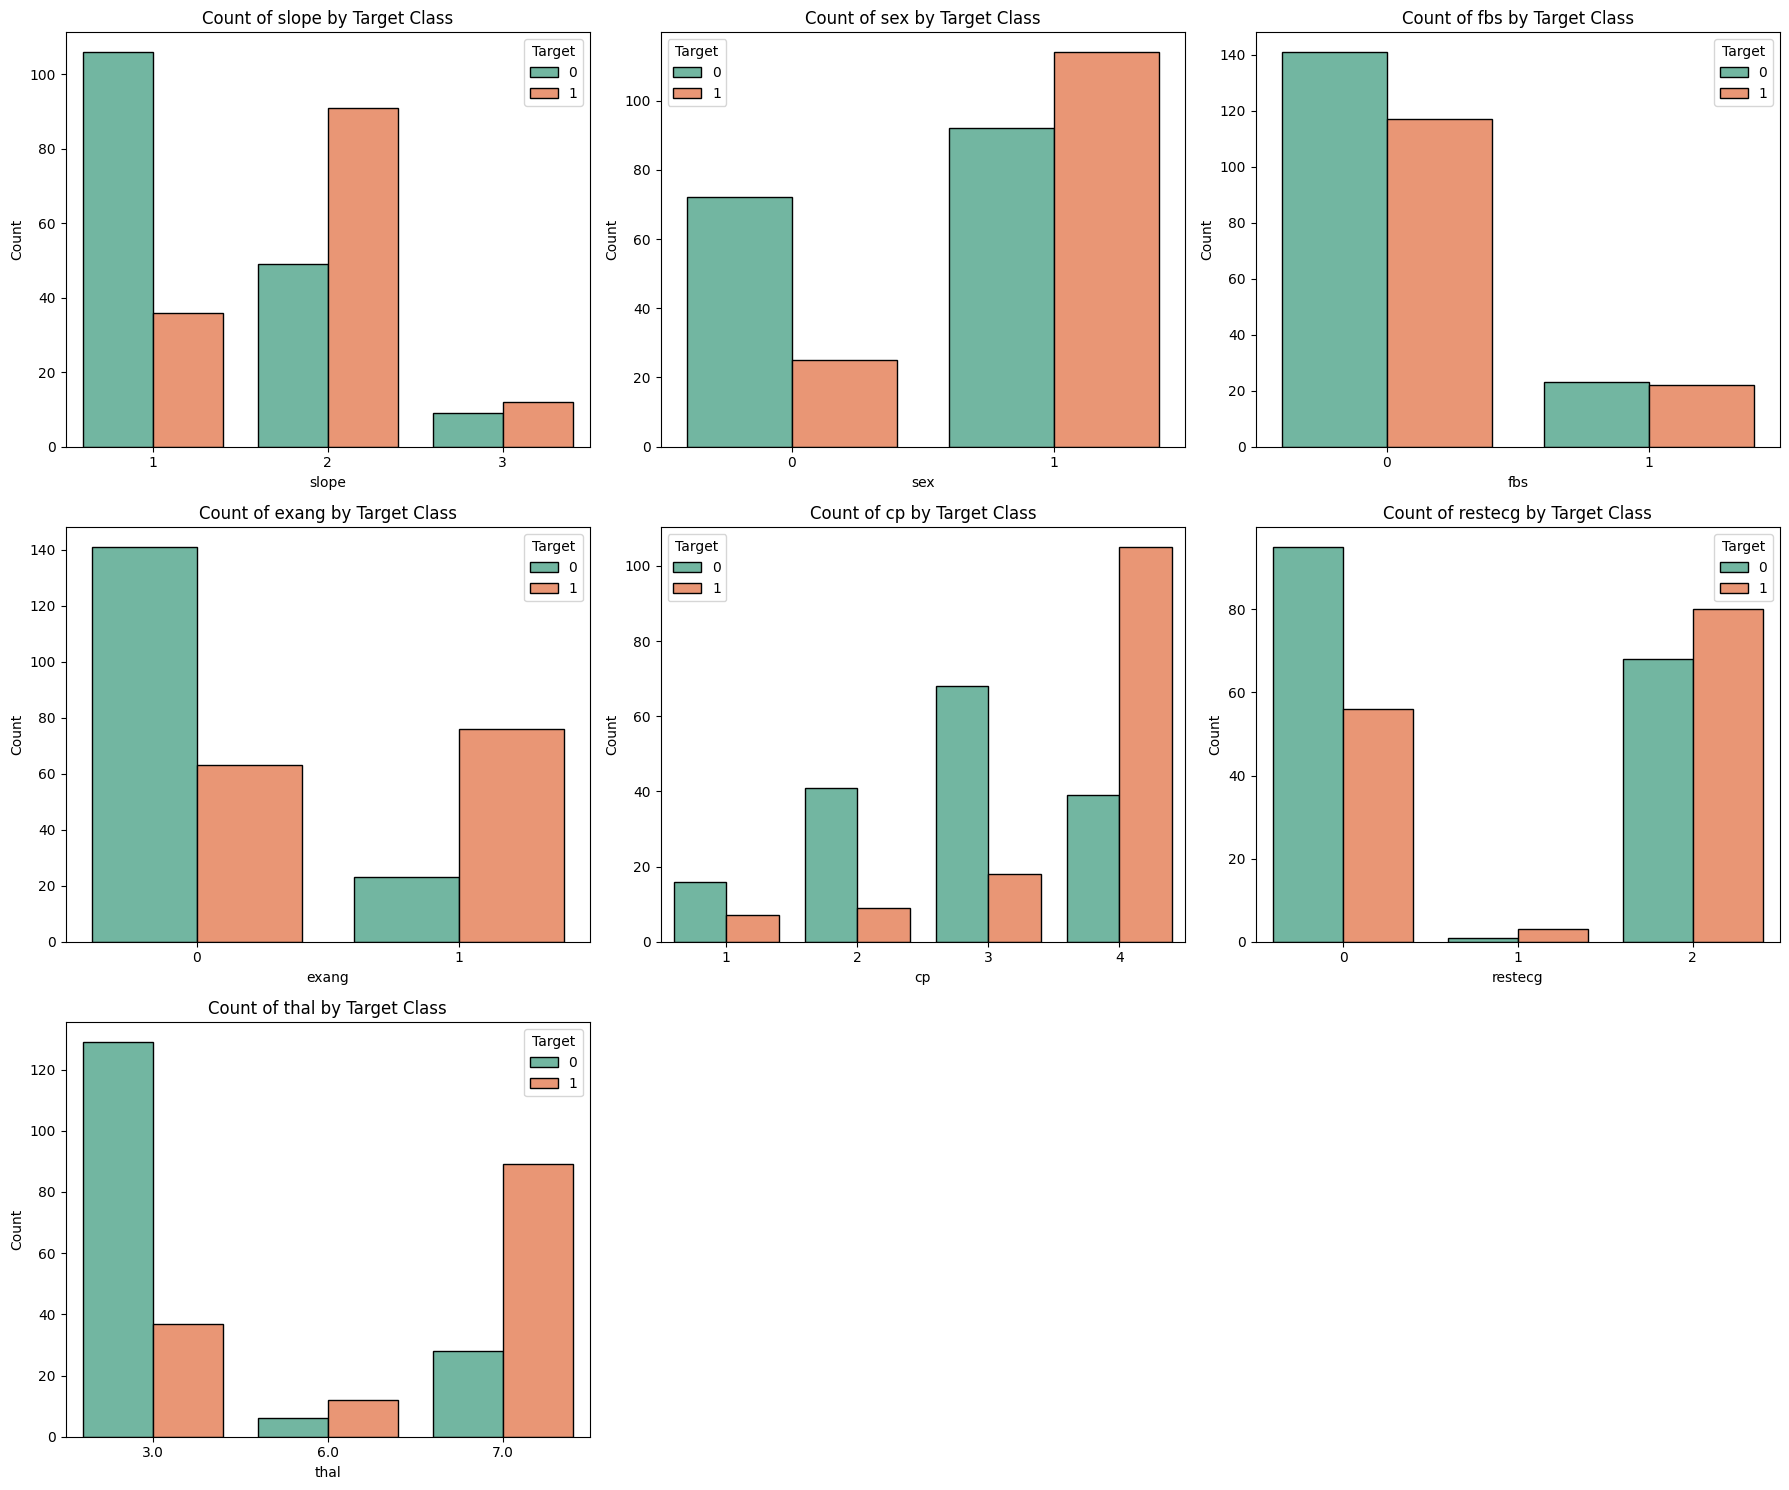

In [ ]:
n_cols = 3
n_rows = (len(cat_data_uci.columns) + n_cols - 1) // n_cols  # enough rows for all columns

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(n_cols * 6, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(cat_data_uci.columns):
    ax = axes[i]
    sns.countplot(x=cat_data_uci[col], hue=uci['num'], ax=ax, palette='Set2', edgecolor='black')
    ax.set_title(f'Count of {col} by Target Class')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.legend(title='Target', labels=['0', '1'])

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


### **Stacked Bar Plots**

> Same as the bar plots by `target` class above

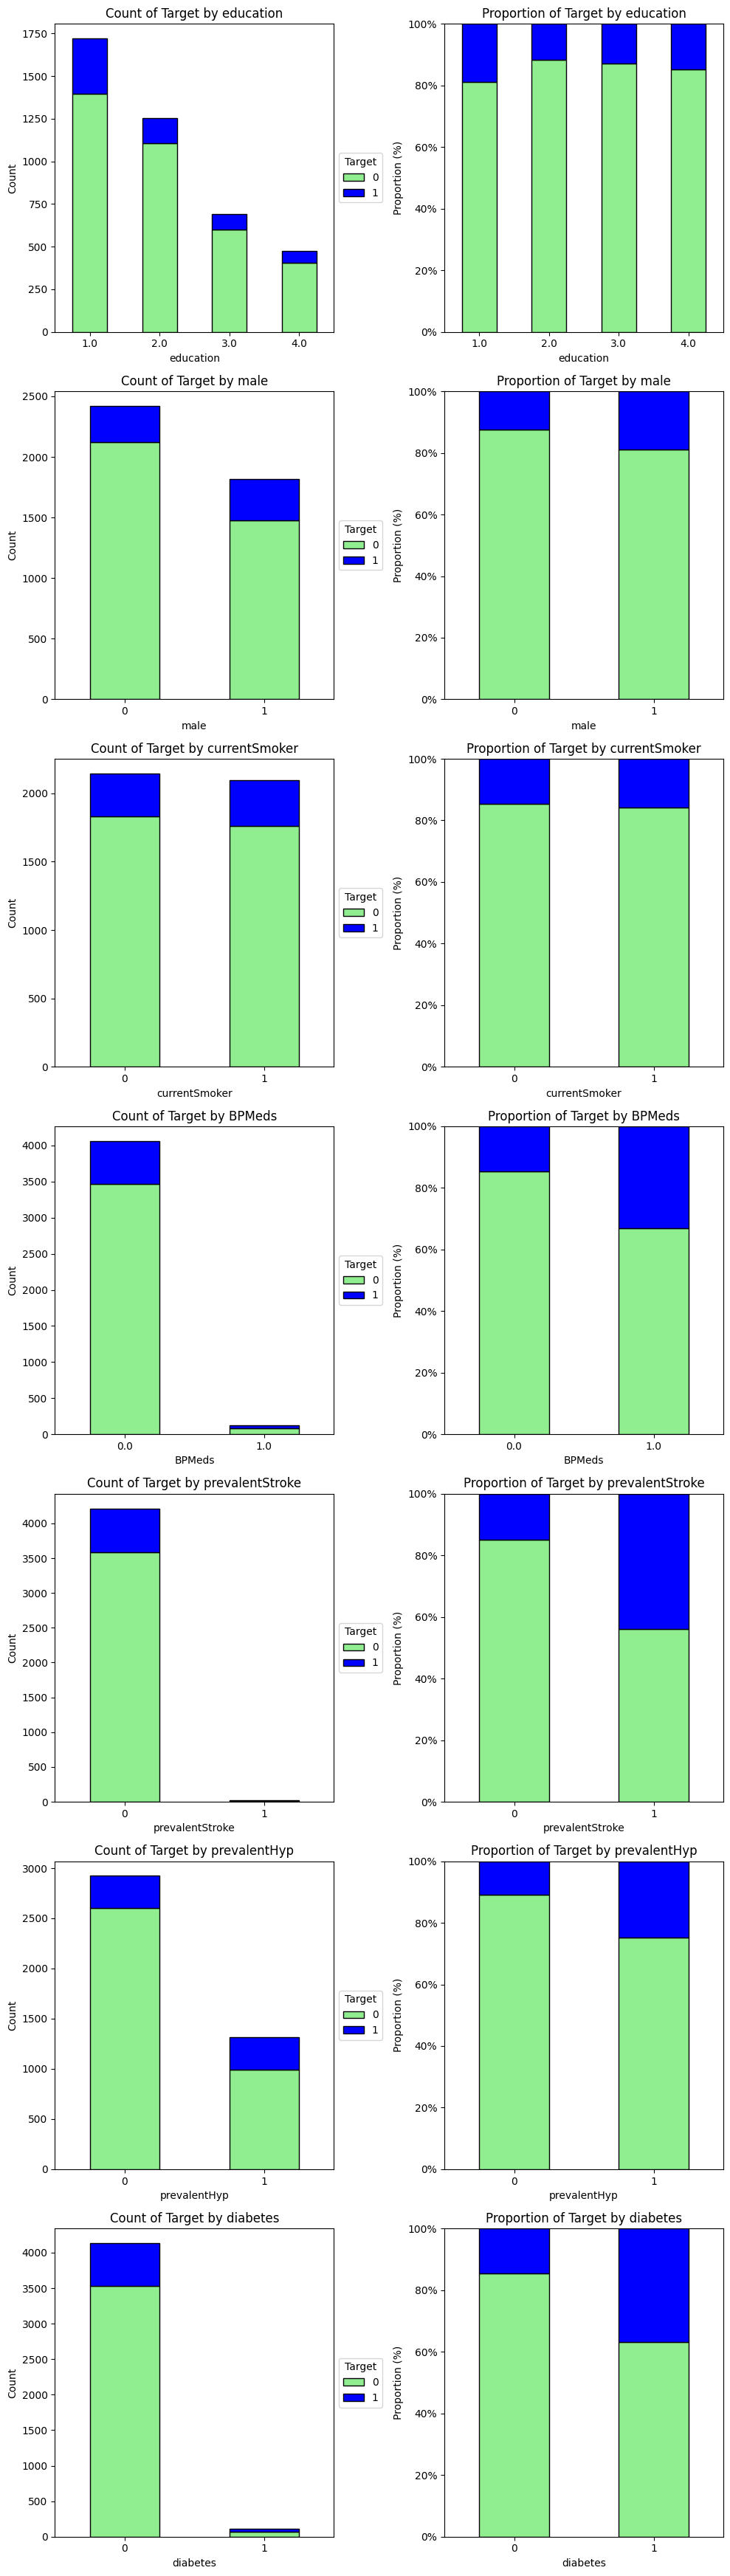

In [ ]:
n_cols = 2
n_rows = len(cat_data_fram.columns)

plt.figure(figsize=(n_cols * 5, n_rows * 5))
for i, col in enumerate(cat_data_fram.columns):
    ctab = pd.crosstab( cat_data_fram[col], fram['TenYearCHD'])

    # (1st col) add new subplot interactively for count values
    ax1 = plt.subplot(n_rows, n_cols, i * n_cols + 1)

    # Stacked bar plot for counts
    ctab.plot(kind='bar', stacked=True, ax=ax1, color=['lightgreen', 'blue'], edgecolor='black')

    ax1.set_title(f'Count of Target by {col}')
    ax1.set_xlabel(col)
    ax1.set_ylabel('Count')
    ax1.legend(title='Target', loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xticks(rotation=0)

    # (2nd col) add new subplot interactively for proportion values
    ax2 = plt.subplot(n_rows, n_cols, i * n_cols + 2)

    # Normalized stacked bar plot for proportions
    ctab_norm = ctab.div(ctab.sum(axis=1), axis=0) * 100

    # Stacked bar plot for proportions
    ctab_norm.plot(kind='bar', stacked=True, ax=ax2, color=['lightgreen', 'blue'], edgecolor='black')

    ax2.set_title(f'Proportion of Target by {col}')
    ax2.set_xlabel(col)
    ax2.set_ylabel('Proportion (%)')
    ax2.legend().remove()
    plt.xticks(rotation=0)

    # yticks as percentage
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, loc: "{:.0f}%".format(int(y))))
    ax2.set_ylim(0, 100)

plt.tight_layout()
plt.show()

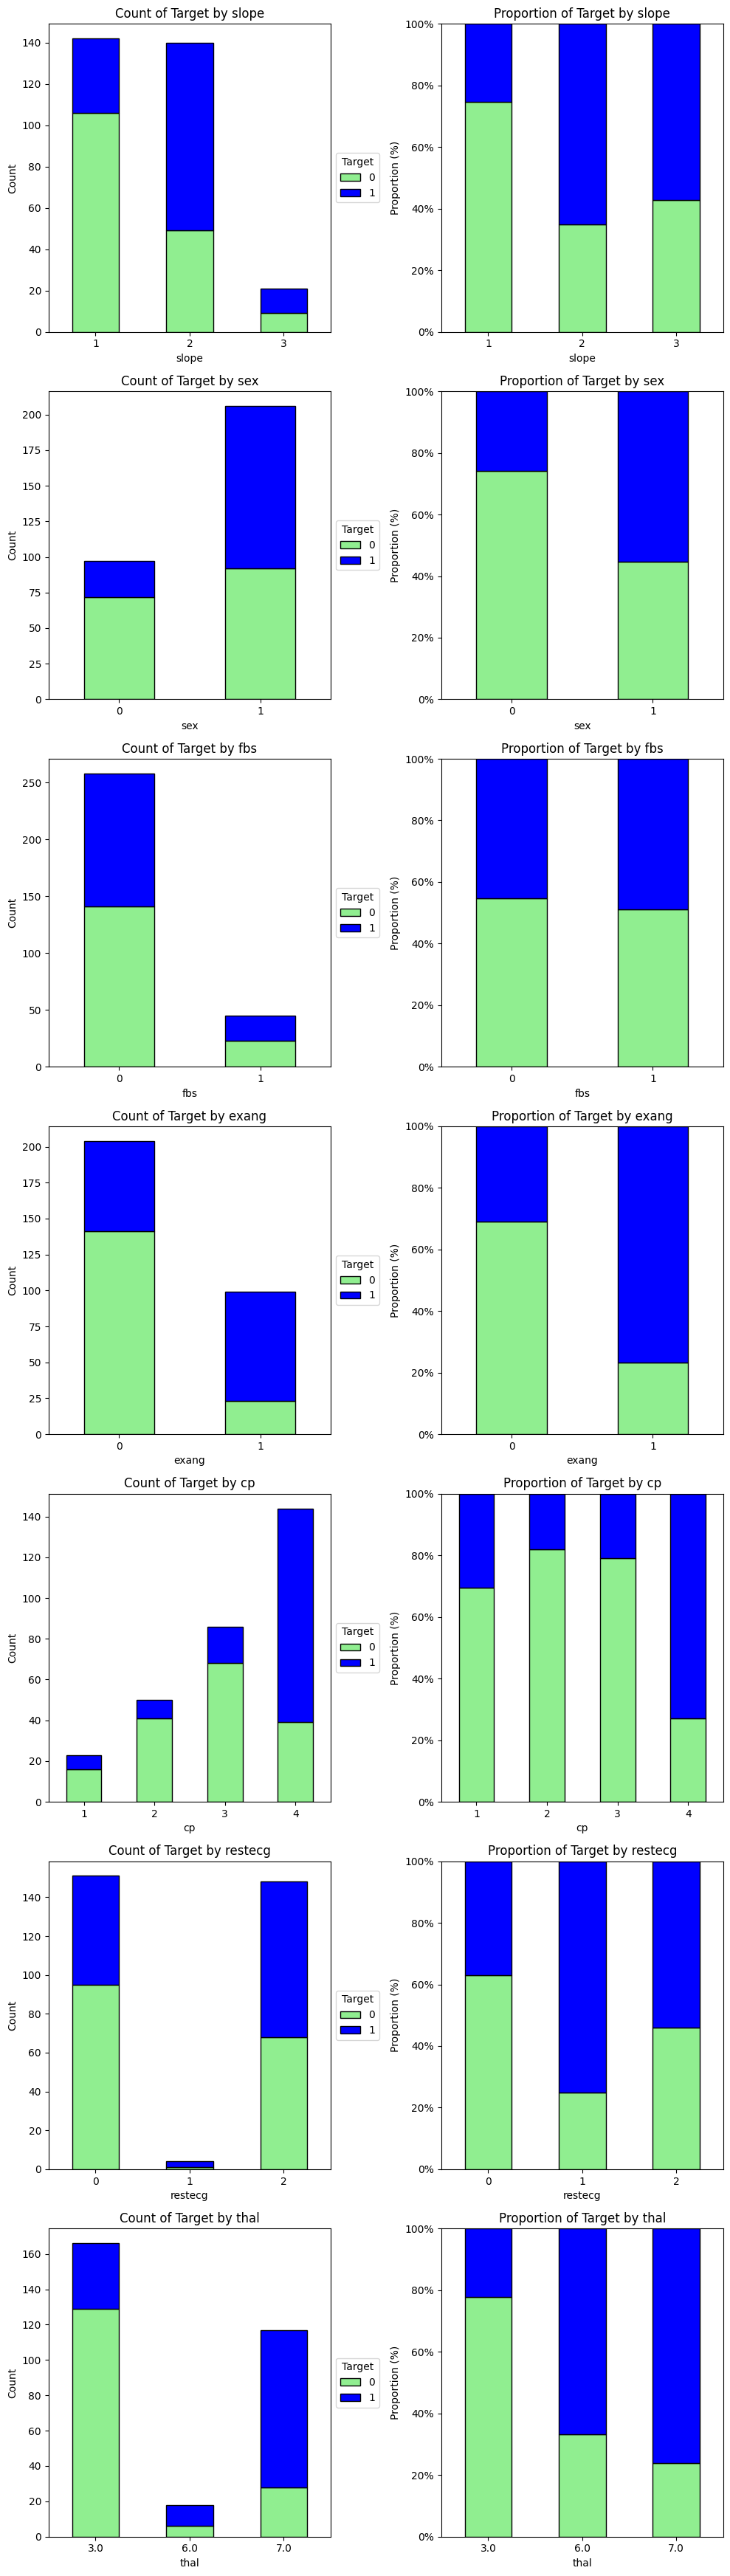

In [ ]:
n_cols = 2
n_rows = len(cat_data_uci.columns)

plt.figure(figsize=(n_cols * 5, n_rows * 5))
for i, col in enumerate(cat_data_uci.columns):
    ctab = pd.crosstab( cat_data_uci[col], uci['num'])

    # (1st col) add new subplot interactively for count values
    ax1 = plt.subplot(n_rows, n_cols, i * n_cols + 1)

    # Stacked bar plot for counts
    ctab.plot(kind='bar', stacked=True, ax=ax1, color=['lightgreen', 'blue'], edgecolor='black')

    ax1.set_title(f'Count of Target by {col}')
    ax1.set_xlabel(col)
    ax1.set_ylabel('Count')
    ax1.legend(title='Target', loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xticks(rotation=0)

    # (2nd col) add new subplot interactively for proportion values
    ax2 = plt.subplot(n_rows, n_cols, i * n_cols + 2)

    # Normalized stacked bar plot for proportions
    ctab_norm = ctab.div(ctab.sum(axis=1), axis=0) * 100

    # Stacked bar plot for proportions
    ctab_norm.plot(kind='bar', stacked=True, ax=ax2, color=['lightgreen', 'blue'], edgecolor='black')

    ax2.set_title(f'Proportion of Target by {col}')
    ax2.set_xlabel(col)
    ax2.set_ylabel('Proportion (%)')
    ax2.legend().remove()
    plt.xticks(rotation=0)

    # yticks as percentage
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, loc: "{:.0f}%".format(int(y))))
    ax2.set_ylim(0, 100)

plt.tight_layout()
plt.show()